In [4]:
import numpy as np
import matplotlib.pyplot as plt

In [5]:
x = np.array([
    [1.0, 1.0], [1.5, 1.2], [2.0, 1.8], [2.2, 2.0],
    [2.5, 2.3], [3.0, 2.8], [3.2, 3.0], [3.5, 3.2],
    [4.0, 3.8], [4.5, 4.0], [5.0, 4.5], [5.5, 5.0]
])

y = np.array([0,0,0,0,0,0,1,1,1,1,1,1])
print(x.shape)
print(y.shape)

(12, 2)
(12,)


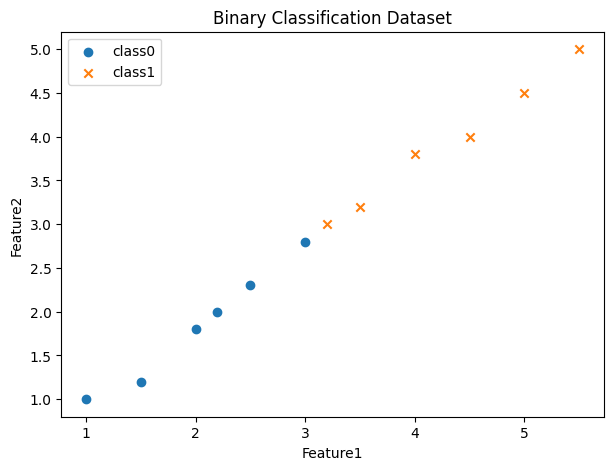

In [6]:
#visualize
plt.figure(figsize=(7,5))
plt.scatter(x[y==0,0],x[y==0,1],marker='o',label='class0')
plt.scatter(x[y==1,0],x[y==1,1],marker='x',label='class1')
plt.xlabel("Feature1")
plt.ylabel("Feature2")
plt.title("Binary Classification Dataset")
plt.legend()
plt.show()

In [7]:
#sigmoid function
def sigmoid(z):
  return 1/(1+np.exp(-z))
#test sigmoid
test_values=np.array([-10,-2,0,2,10])
print("Sigmoid values for the given test values [-10,-2,0,2,10] :",sigmoid(test_values))


Sigmoid values for the given test values [-10,-2,0,2,10] : [4.53978687e-05 1.19202922e-01 5.00000000e-01 8.80797078e-01
 9.99954602e-01]


In [8]:
#compute linear score
def compute_z(x,w,b):
  return x @ w + b
w=np.zeros(x.shape[1])
b=0.0
z=compute_z(x,w,b)
print("z:",z)
print("Z schape",z.shape)

z: [0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]
Z schape (12,)


In [9]:
#predict probabilities
def predict_probabilities(x,w,b):
  z=compute_z(x,w,b)
  y_hat=sigmoid(z)
  return y_hat
probabilities=predict_probabilities(x,w,b)
print("Predicted probabilities:",probabilities)

Predicted probabilities: [0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5 0.5]


COST FUNCTION:
$$J(\theta) = -\frac{1}{m} \sum_{i=1}^{m} \left[ y^{(i)} \log(\hat{y}^{(i)}) + (1 - y^{(i)}) \log(1 - \hat{y}^{(i)}) \right]$$


In [10]:
def compute_cost(x,y,w,b):
  m=x.shape[0]
  probabilities=predict_probabilities(x,w,b)
  #avoid log0
  epsilon=1e-15
  probabilities=np.clip(probabilities,epsilon,1-epsilon)
  cost=(-1/m)*np.sum(y*np.log(probabilities)+(1-y)*np.log(1-probabilities))
  return cost
initial_cost=compute_cost(x,y,w,b)
print("Initial cost:",initial_cost)


Initial cost: 0.6931471805599452


In [11]:
#gradient descent
def compute_gradients(x,y,w,b):
  m=x.shape[0]
  probabilities=predict_probabilities(x,w,b)

  dw=(1/m)*(x.T @ (probabilities-y))
  db=(1/m)*np.sum(probabilities-y)

  return dw,db
dw,db=compute_gradients(x,y,w,b)
print("dw:",dw)
print("db:",db)


dw: [-0.5625     -0.51666667]
db: 0.0


In [12]:
#one gradient descent update
def gradient_descent_step(x,y,w,b,learning_rate):
  dw,db=compute_gradients(x,y,w,b)
  w=w-learning_rate*dw
  b=b-learning_rate*db
  return w,b

In [13]:
def train_logistic_regression(x,y,learning_rate=0.1,num_iteration=1000):
  w=np.zeros(x.shape[1])
  b=0.0
  cost_history=[]
  for i in range(num_iteration):
    cost=compute_cost(x,y,w,b)

    #calculate gradients
    dw,db=compute_gradients(x,y,w,b)
    #update weight & bias
    w=w-learning_rate*dw
    b=b-learning_rate*db
    cost_history.append(cost)
  return w,b,cost_history


In [15]:
w, b, cost_history = train_logistic_regression(
    x,
    y,
    learning_rate=0.1,
    num_iteration=1000
)


In [19]:
print("W",w)
print("b",b)
print("cost_history",cost_history[-1])

W [0.93237099 1.04970645]
b -5.656246822064308
cost_history 0.20888817201258197


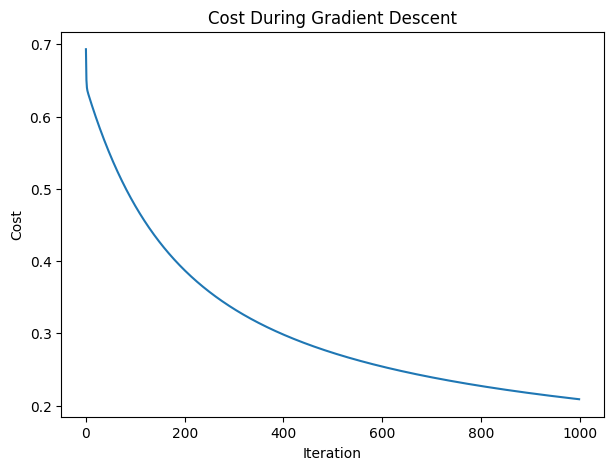

In [20]:
plt.figure(figsize=(7,5))

plt.plot(cost_history)

plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost During Gradient Descent")

plt.show()

In [22]:
def predict(X_input, w, b, threshold=0.5):
    probabilities = predict_probabilities(X_input, w, b)
    predictions = (probabilities >= threshold).astype(int)
    return predictions
# Predictions
y_pred = predict(x, w, b)
print("Predictions:", y_pred)
print("Actual:     ", y)

Predictions: [0 0 0 0 0 1 1 1 1 1 1 1]
Actual:      [0 0 0 0 0 0 1 1 1 1 1 1]


In [23]:
def accuracy(y_true, y_pred):
   return np.mean(y_true == y_pred)
print("Accuracy:", accuracy(y, y_pred))

Accuracy: 0.9166666666666666


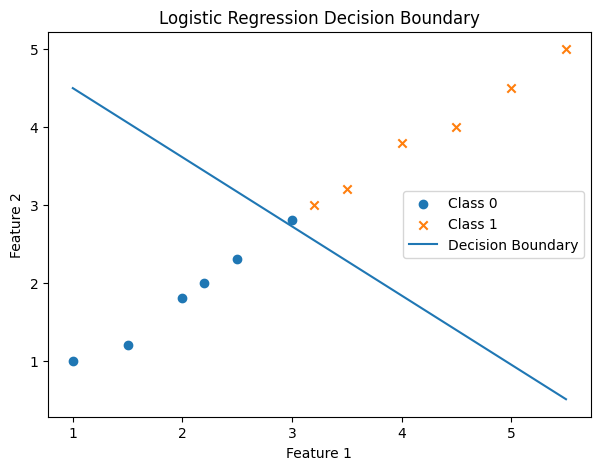

In [25]:
# 15. DECISION BOUNDARY
plt.figure(figsize=(7,5))
# Plot Class 0
plt.scatter(
    x[y == 0, 0],
    x[y == 0, 1],
    marker='o',
    label='Class 0'
)
# Plot Class 1
plt.scatter(
    x[y == 1, 0],
    x[y == 1, 1],
    marker='x',
    label='Class 1'
)
# Values for Feature 1
x1 = np.linspace(
    x[:, 0].min(),
    x[:, 0].max(),
    100
)
# Decision boundary:
# w1*x1 + w2*x2 + b = 0
#
# x2 = -(w1*x1 + b) / w2

x2 = -(w[0] * x1 + b) / w[1]
plt.plot(
    x1,
    x2,
    label='Decision Boundary'
)
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()